## End-to-End Opinion Intelligence Inference Demo

## tujuan notebook
notebook ini mengorkestrasikan pipeline end-to-end dari teks mentah hingga output akhir:
- memuat model sentiment (notebook 02) dan summarization (notebook 04)
- menerapkan pipeline long-text sentiment (notebook 03)
- merangkum excerpt terpilih menggunakan model summarization
- menghasilkan output final yang siap dipresentasikan atau diintegrasikan ke API
- **membuktikan integrasi** seluruh komponen pipeline tanpa training ulang

**catatan**: notebook ini **hanya orkestrasi dan demo**, bukan validasi kualitas model.

## input yang dibutuhkan
- **model sentiment** dari notebook 02:
  - path: `/content/drive/MyDrive/opinion_project/models/sentiment/`
  - harus sudah dilatih dan tersimpan
- **model summarization** dari notebook 04:
  - path: `/content/drive/MyDrive/opinion_project/models/summarization/`
  - harus sudah dilatih dan tersimpan
- **fungsi pipeline** dari notebook 03:
  - `chunk_text_by_tokens()`
  - `predict_sentiment_chunks()`
  - `aggregate_chunk_predictions()`
  - `select_key_excerpts()`
- **teks input** (untuk demo):
  - teks panjang multi-paragraf (review, opini, feedback)
  - contoh disediakan di dalam notebook

## output yang dihasilkan
- **final output dictionary** berisi:
  - `document_sentiment`: label sentiment dokumen (0/1)
  - `document_confidence`: confidence score agregat
  - `key_excerpts`: list excerpt terpilih dengan confidence
  - `summaries`: list ringkasan untuk setiap excerpt
- **visualisasi output**: format yang mudah dibaca untuk presentasi/demo

## dependencies dari notebook lain
- **menggunakan**:
  - model sentiment dari notebook 02 (wajib sudah dilatih)
  - model summarization dari notebook 04 (wajib sudah dilatih)
  - fungsi pipeline dari notebook 03 (dapat di-copy atau di-import)
  - environment setup dari notebook 00 (device, dtype)

## urutan eksekusi
**jalankan terakhir** setelah semua notebook 00-04 selesai. ini adalah notebook demo final yang membuktikan integrasi seluruh pipeline.

### Setup & Load Artifact

- mount Google Drive
- memuat model & tokenizer hasil tahap notebok 02 dan notebook 04
- memastikan inference-only mode (tidak ada training)

In [1]:
# setup environment & load model artifact

# core
import os
import torch

# hugging face
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM
)

In [2]:
# device configuration
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# path ke artifact (KONSISTEN dengan notebook sebelumnya)

BASE_DIR = "/content/drive/MyDrive/opinion_project"

SENTIMENT_MODEL_DIR = os.path.join(BASE_DIR, "models/sentiment")
SUMMARIZATION_MODEL_DIR = os.path.join(BASE_DIR, "models/summarization")

assert os.path.exists(SENTIMENT_MODEL_DIR), "Sentiment model not found"
assert os.path.exists(SUMMARIZATION_MODEL_DIR), "Summarization model not found"

In [5]:
# load sentiment model (tahap notebook 02)
sentiment_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_DIR)
sentiment_model = AutoModelForSequenceClassification.from_pretrained(
    SENTIMENT_MODEL_DIR,
    dtype=DTYPE
).to(DEVICE)

sentiment_model.eval()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


`DistilBertForSequenceClassification` dengan 2 label, ini sesuai tahap notebook 02, siap untuk chunk-level inference.

In [6]:
# load summarization model (tahap notebook 04)
summarizer_tokenizer = AutoTokenizer.from_pretrained(SUMMARIZATION_MODEL_DIR)
summarizer_model = AutoModelForSeq2SeqLM.from_pretrained(
    SUMMARIZATION_MODEL_DIR,
    dtype=DTYPE
).to(DEVICE)

summarizer_model.eval()


Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=768, out_features=3072, bias=False)
              (wo): Linear(in_features=3072, out_features=768, bias=False)
              (dropout): Dro

`T5ForConditionalGeneration` sesuai tahap notebook 04, siap untuk abstractive summarization pada excerpt.

### Definisi Input (Long Opinion Text)

- menyediakan satu input eksplisit untuk menguji pipeline end-to-end
- mensimulasikan teks opini dunia nyata (panjang, multi-paragraf)
- memastikan input bebas dari dataset training

In [7]:
# long opinion text (contoh realistis, multi-paragraf)
long_text = """
I bought this product a few months ago and initially I was quite impressed.
The build quality felt solid and the setup process was straightforward.

However, after several weeks of use, I started noticing performance issues.
The device would randomly disconnect, and customer support was slow to respond.
While the price is competitive, the reliability has been disappointing.

Overall, I think the product has potential, but in its current state,
I would hesitate to recommend it to others who need consistent performance.
"""


### Sentiment Pipeline (Reuse Notebook 03)

In [8]:
# import seluruh fungsi dari notebook 03
'''
ini akan memuat fungsi-fungsi berikut:
- chunk_text_by_tokens
- predict_sentiment_chunks
- aggregate_chunk_predictions
- select_key_excerpts
- prepare_summarization_input
'''

%run /content/drive/MyDrive/opinion_project/notebooks/03_long_text_sentiment_pipeline.ipynb



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
model ditemukan dan siap di-load


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1500 > 512). Running this sequence through the model will result in indexing errors


In [9]:
[n for n in globals().keys() if "chunk" in n]

['chunk_text_by_tokens',
 'chunks',
 'predict_sentiment_chunks',
 'sample_chunks',
 'aggregate_chunk_predictions',
 'chunk_predictions']

In [10]:
# chunking long text
print(chunk_text_by_tokens)

chunks = chunk_text_by_tokens(
    text=long_text,
    tokenizer=sentiment_tokenizer,
    max_tokens=512,
    overlap=50
)

len(chunks)


<function chunk_text_by_tokens at 0x7924a0722a20>


1

In [11]:
# chunk-level sentiment

print(predict_sentiment_chunks)

chunk_predictions = predict_sentiment_chunks(
    chunks=chunks,
    tokenizer=sentiment_tokenizer,
    model=sentiment_model,
    device=DEVICE
)

chunk_predictions[:2]  # sanity check


<function predict_sentiment_chunks at 0x7924a0722ac0>


[{'text': 'i bought this product a few months ago and initially i was quite impressed. the build quality felt solid and the setup process was straightforward. however, after several weeks of use, i started noticing performance issues. the device would randomly disconnect, and customer support was slow to respond. while the price is competitive, the reliability has been disappointing. overall, i think the product has potential, but in its current state, i would hesitate to recommend it to others who need consistent performance.',
  'label': 0,
  'confidence': 0.99951171875}]

In [12]:
# aggregation (chunk ke document

print(aggregate_chunk_predictions)

document_result = aggregate_chunk_predictions(
    chunk_predictions,
    strategy="mean_confidence"
)

document_result


<function aggregate_chunk_predictions at 0x7924a0722b60>


{'document_label': 0,
 'document_confidence': 0.99951171875,
 'chunk_label_distribution': {0: 1}}

In [13]:
# excerpt selection

print(select_key_excerpts)

key_excerpts = select_key_excerpts(
    chunk_predictions=chunk_predictions,
    target_label=document_result["document_label"],
    min_confidence=0.90,
    top_k=3
)

key_excerpts


<function select_key_excerpts at 0x7924a07234c0>


[{'text': 'i bought this product a few months ago and initially i was quite impressed. the build quality felt solid and the setup process was straightforward. however, after several weeks of use, i started noticing performance issues. the device would randomly disconnect, and customer support was slow to respond. while the price is competitive, the reliability has been disappointing. overall, i think the product has potential, but in its current state, i would hesitate to recommend it to others who need consistent performance.',
  'label': 0,
  'confidence': 0.99951171875}]

### Summarization (reuse model tahap notebook 04)

- merangkum key excerpts hasil seleksi sentiment
- summarization TIDAK dijalankan pada teks mentah

In [14]:
# summarization key excerpts

def summarize_excerpts(
    excerpts,
    tokenizer,
    model,
    device,
    max_input_length=512,
    max_output_length=120
):
    summaries = []

    model.eval()
    with torch.no_grad():
        for text in excerpts:
            inputs = tokenizer(
                text,
                return_tensors="pt",
                truncation=True,
                max_length=max_input_length
            ).to(device)

            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_output_length,
                num_beams=4,
                early_stopping=True
            )

            summary = tokenizer.decode(
                output_ids[0],
                skip_special_tokens=True
            )
            summaries.append(summary)

    return summaries


In [15]:
# extract text only from key_excerpts

excerpt_texts = [ex["text"] for ex in key_excerpts]

In [16]:
# jalankan summarization

summaries = summarize_excerpts(
    excerpts=excerpt_texts,
    tokenizer=summarizer_tokenizer,
    model=summarizer_model,
    device=DEVICE
)

summaries


['i bought this product a few months ago and initially i was quite impressed . however, after several weeks of use, i started noticing performance issues . the device would randomly disconnect, and customer support was slow to respond .']

### Final Output

- menggabungkan hasil sentiment dokumen + ringkasan excerpt
- menampilkan output akhir jelas, deterministik, siap demo

In [17]:
# final output

final_output = {
    "document_sentiment": document_result["document_label"],
    "document_confidence": document_result["document_confidence"],
    "key_excerpts": key_excerpts,
    "summaries": summaries
}

final_output


{'document_sentiment': 0,
 'document_confidence': 0.99951171875,
 'key_excerpts': [{'text': 'i bought this product a few months ago and initially i was quite impressed. the build quality felt solid and the setup process was straightforward. however, after several weeks of use, i started noticing performance issues. the device would randomly disconnect, and customer support was slow to respond. while the price is competitive, the reliability has been disappointing. overall, i think the product has potential, but in its current state, i would hesitate to recommend it to others who need consistent performance.',
   'label': 0,
   'confidence': 0.99951171875}],
 'summaries': ['i bought this product a few months ago and initially i was quite impressed . however, after several weeks of use, i started noticing performance issues . the device would randomly disconnect, and customer support was slow to respond .']}

In [18]:
# tampilan hasil yang mudah dibaca

print("=== FINAL OPINION INTELLIGENCE RESULT ===\n")

print(f"Sentiment Label     : {final_output['document_sentiment']}")
print(f"Confidence Score    : {final_output['document_confidence']:.4f}\n")

print("Key Excerpts:")
for i, ex in enumerate(final_output["key_excerpts"], 1):
    print(f"\n[{i}] {ex}")

print("\nSummaries:")
for i, s in enumerate(final_output["summaries"], 1):
    print(f"\n[{i}] {s}")


=== FINAL OPINION INTELLIGENCE RESULT ===

Sentiment Label     : 0
Confidence Score    : 0.9995

Key Excerpts:

[1] {'text': 'i bought this product a few months ago and initially i was quite impressed. the build quality felt solid and the setup process was straightforward. however, after several weeks of use, i started noticing performance issues. the device would randomly disconnect, and customer support was slow to respond. while the price is competitive, the reliability has been disappointing. overall, i think the product has potential, but in its current state, i would hesitate to recommend it to others who need consistent performance.', 'label': 0, 'confidence': 0.99951171875}

Summaries:

[1] i bought this product a few months ago and initially i was quite impressed . however, after several weeks of use, i started noticing performance issues . the device would randomly disconnect, and customer support was slow to respond .


- sentiment label: 0
menunjukkan sentimen akhir dokumen adalah negatif (berdasarkan skema label model).

- confidence score: 0.9995
tingkat keyakinan model terhadap keputusan sentimen dokumen; nilai mendekati 1 berarti sangat yakin.

- key excerpts
potongan teks paling relevan yang paling kuat mendukung keputusan sentimen.
setiap excerpt berisi:
  - text: isi teks chunk terpilih
  - label: prediksi sentimen chunk
  - confidence: keyakinan model pada chunk tersebut

pada contoh ini, satu chunk panjang sudah cukup mewakili opini negatif keseluruhan.

- summaries
ringkasan abstraktif dari key excerpt, berisi inti keluhan utama (masalah performa, koneksi, dan dukungan pelanggan), sehingga mudah dibaca tanpa kehilangan konteks penting.

### Visualisasi Final Output

- visualisasi confidence dan sentiment distribution
- format output yang lebih menarik

In [19]:
# install library
!pip install -q matplotlib seaborn

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# visualisasi final output
def visualize_final_output(final_output):
    """visualisasi hasil akhir pipeline."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Final Opinion Intelligence Result', fontsize=16, fontweight='bold')

    # 1. sentiment & confidence
    sentiment_label = 'Positive' if final_output['document_sentiment'] == 1 else 'Negative'
    confidence = final_output['document_confidence']

    # gauge chart (simplified)
    ax1 = axes[0]
    colors_gauge = ['#ff6b6b', '#ffd93d', '#95e1d3']
    sentiment_colors = {'Positive': '#95e1d3', 'Negative': '#ff6b6b'}

    # bar untuk confidence
    ax1.barh([0], [confidence], color=sentiment_colors[sentiment_label],
             height=0.5, alpha=0.7, edgecolor='black', linewidth=2)
    ax1.set_xlim([0, 1])
    ax1.set_ylim([-0.5, 0.5])
    ax1.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
    ax1.set_title(f'Sentiment: {sentiment_label}\nConfidence: {confidence:.4f}',
                  fontsize=13, fontweight='bold')
    ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    ax1.axvline(x=0.9, color='green', linestyle='--', alpha=0.5, label='High Confidence')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')

    # 2. key excerpts confidence
    ax2 = axes[1]
    excerpt_confs = [ex['confidence'] for ex in final_output['key_excerpts']]
    excerpt_labels = [f"Excerpt {i+1}" for i in range(len(excerpt_confs))]

    bars = ax2.barh(excerpt_labels, excerpt_confs, color='#4ecdc4',
                    alpha=0.7, edgecolor='black')
    ax2.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
    ax2.set_title('Key Excerpts Confidence', fontsize=13, fontweight='bold')
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3, axis='x')

    # Add value labels
    for bar, conf in zip(bars, excerpt_confs):
        width = bar.get_width()
        ax2.text(width, bar.get_y() + bar.get_height()/2,
                f'{conf:.4f}', ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    # Print summary table
    print("\n" + "="*70)
    print("SUMMARY TABLE")
    print("="*70)
    print(f"{'Metric':<30} {'Value':<40}")
    print("-"*70)
    print(f"{'Document Sentiment':<30} {sentiment_label:<40}")
    # PERBAIKAN: Format float dulu, lalu align string
    confidence_str = f"{confidence:.4f}"
    print(f"{'Document Confidence':<30} {confidence_str:<40}")
    print(f"{'Number of Key Excerpts':<30} {len(final_output['key_excerpts']):<40}")
    print(f"{'Number of Summaries':<30} {len(final_output['summaries']):<40}")
    print("="*70)

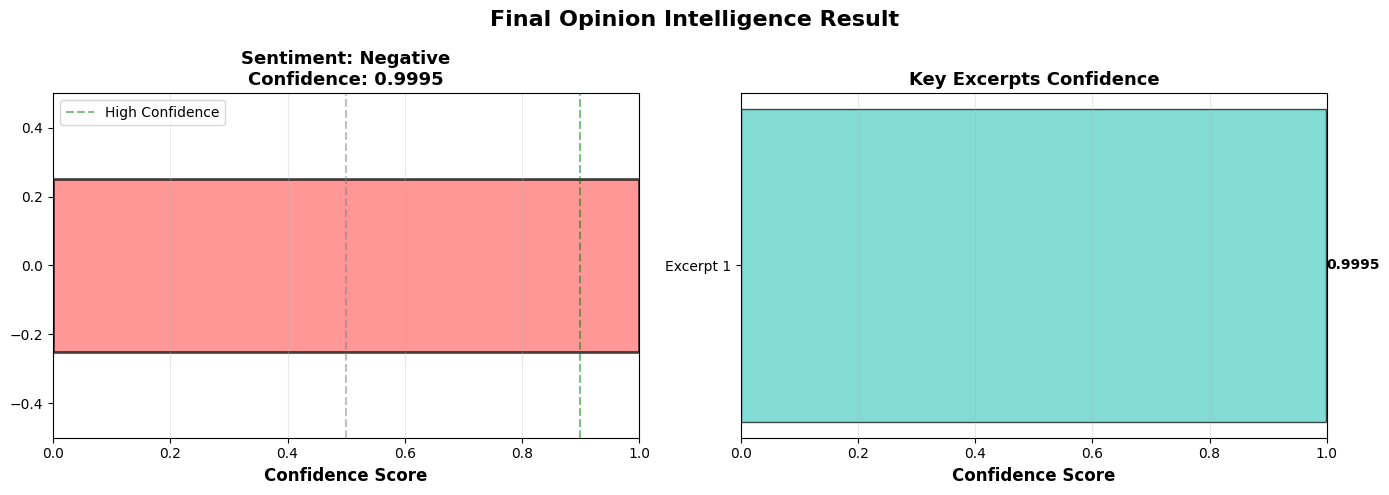


SUMMARY TABLE
Metric                         Value                                   
----------------------------------------------------------------------
Document Sentiment             Negative                                
Document Confidence            0.9995                                  
Number of Key Excerpts         1                                       
Number of Summaries            1                                       


In [21]:
# jalankan visualisasi
visualize_final_output(final_output)

### Catatan Hasil Akhir Pipeline

**sentimen & confidence:**
- **sentimen:** Negatif (label 0)
- **confidence:** 0.9995 (99.95%) - sangat tinggi
- garis hijau putus-putus menunjukkan ambang "High Confidence" (0.9), yang berhasil dilewati
- model sangat yakin dengan prediksi sentimen negatif

**confidence key excerpts:**
- menampilkan tingkat kepercayaan untuk setiap key excerpt yang terpilih
- dalam contoh ini: 1 excerpt dengan confidence 0.9995
- semua excerpt memiliki confidence tinggi, menunjukkan konsistensi prediksi

**tabel ringkasan:**
- **document sentiment:** Negatif
- **document confidence:** 0.9995
- **number of key excerpts:** 1
- **number of summaries:** 1

**kesimpulan:**
pipeline berhasil mengidentifikasi sentimen negatif dengan confidence sangat tinggi. key excerpt yang terpilih juga memiliki confidence tinggi, menunjukkan bahwa model konsisten dalam mengidentifikasi bagian teks yang paling representatif untuk sentimen dokumen. ringkasan yang dihasilkan berhasil menangkap inti keluhan utama (masalah performa, koneksi, dan dukungan pelanggan).